In [1]:
# 必要なライブラリのimport
import datetime
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

import lightgbm as lgb

#最大表示列数の指定（ここでは50列を指定）
pd.set_option('display.max_columns', 50)

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
# google driveへのマウント
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# データの読み込み
data = pd.read_csv('/content/drive/MyDrive/競馬分析/feature_data/feature_race_result.csv')

In [4]:
# データの分割
# データは2022年1月5日〜2024年7月14日まであるので2024年6月までを学習用、それ以降を検証用としてデータを分割します。

train = data[data['event_date'] < '2024-07-01']
test = data[data['event_date'] >= '2024-07-01']

print('trainデータの件数', len(train))
print('testデータの件数', len(test))

trainデータの件数 119768
testデータの件数 1812


In [5]:
# 説明変数の設定
train_X = train.drop(['race_id', 'event_date', 'finish_position', 'target'], axis=1)
test_X = test.drop(['race_id',  'event_date', 'finish_position', 'target'], axis=1)

# 目的変数の設定
train_y = train['target']
test_y = test['target']

In [6]:
# データをlightgbm用に変換
lgb_train = lgb.Dataset(train_X, train_y)
lgb_eval = lgb.Dataset(test_X, test_y, reference=lgb_train)

# lightGBMのパラメータ設定
params = {
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.01,
    'feature_fraction': 0.8,
    'bagging_freq': 1,
    'bagging_fraction': 0.8,
    'random_state': 0,
    'objective': 'binary',
    'metric': 'binary_logloss'
}

# モデルの学習
model = lgb.train(params, lgb_train,
                               valid_sets=[lgb_train, lgb_eval],
                               num_boost_round=1000,
                               callbacks=[lgb.early_stopping(100),
                                          lgb.log_evaluation(period=100)
                                        ])

[LightGBM] [Info] Number of positive: 26139, number of negative: 93629
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.117817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 119768, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218247 -> initscore=-1.275912
[LightGBM] [Info] Start training from score -1.275912
Training until validation scores don't improve for 100 rounds
[100]	training's binary_logloss: 0.424366	valid_1's binary_logloss: 0.443885
[200]	training's binary_logloss: 0.402209	valid_1's binary_logloss: 0.425171
[300]	training's binary_logloss: 0.39481	valid_1's binary_logloss: 0.421029
[400]	training's binary_logloss: 0.390348	valid_1's binary_logloss: 0.420074
[500]	training's binary_logloss: 0.386335	valid_1's binary_logloss: 0.419921
[600]	training's binary_logloss: 0.382753	valid_1's binary_

<Figure size 1000x700 with 0 Axes>

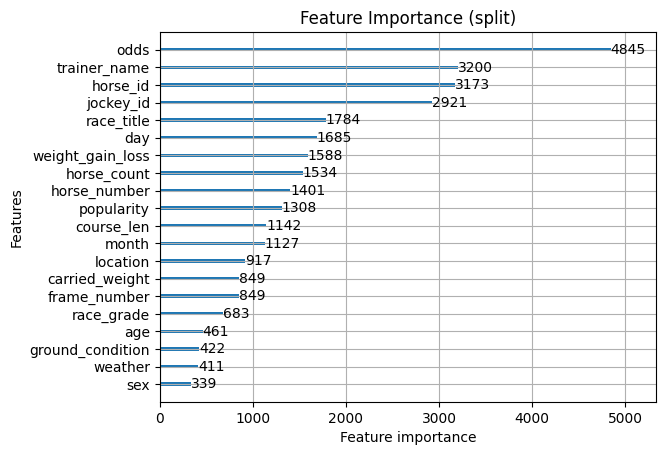

<Figure size 1000x700 with 0 Axes>

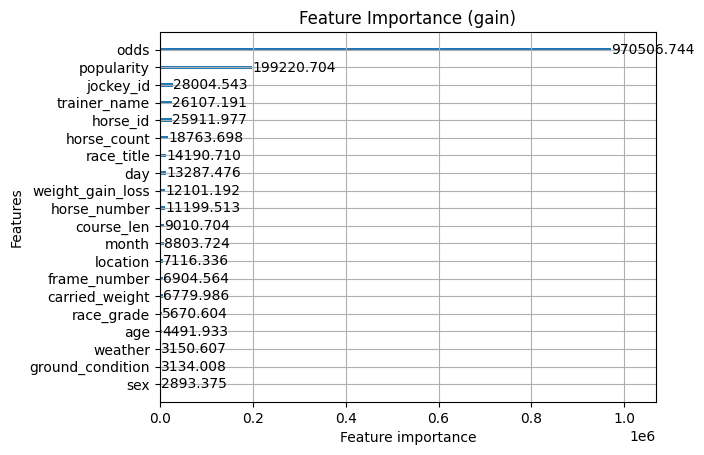

In [7]:
# 特徴量重要度の可視化
plt.figure(figsize=(10, 7))
lgb.plot_importance(model, max_num_features=20, importance_type='split')
plt.title('Feature Importance (split)')
plt.show()

plt.figure(figsize=(10, 7))
lgb.plot_importance(model, max_num_features=20, importance_type='gain')
plt.title('Feature Importance (gain)')
plt.show()

In [ ]:
# 予測の実行(train)
y_pred = model.predict(train_X, num_iteration=model.best_iteration)

# 予測値の代入
train['pred'] = y_pred

<ipython-input-7-f25617f99fba>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['pred'] = y_pred


In [ ]:
# レースごとに確率が高い馬３頭に1,それ以外に0のラベルを付与する処理
# 空のデータフレームとリストを作成
submit = pd.DataFrame()
pred_list = []

for race in train['race_id'].unique():
    # レースごとのデータを抽出
    data = train[train['race_id'] == race]

    # 確率が高い順に並び替え
    data = data.sort_values(by='pred', ascending=False).reset_index()
    for index, data_ in data.iterrows():
        # 上位3頭に1、それ以外の馬に0のラベルを付与
        if index < 3:
            pred_list.append(1)
        else:
            pred_list.append(0)
    submit = pd.concat([submit, data])

# 予測値を格納
submit['pred_class'] = pred_list

# id順に並び替え
submit = submit.sort_values(by='index', ascending=True)

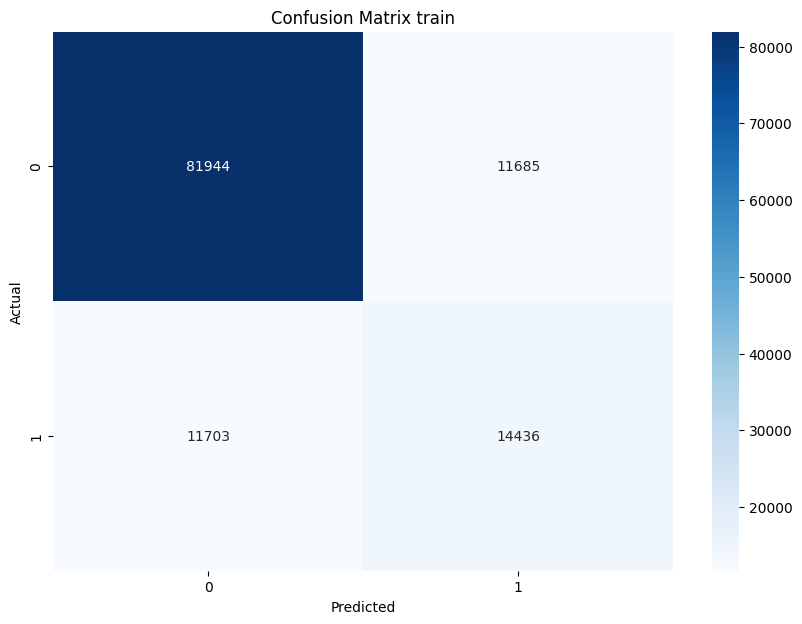

Accuracy: 0.8047224634292967
----------------------------------------------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88     93629
           1       0.55      0.55      0.55     26139

    accuracy                           0.80    119768
   macro avg       0.71      0.71      0.71    119768
weighted avg       0.80      0.80      0.80    119768



In [ ]:
# 予測結果を二値クラスに変換
pred_labels = submit["pred_class"]

# 混合行列の作成
cm = confusion_matrix(train_y, pred_labels)

# 混合行列の可視化
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix train')
plt.show()

# 精度評価の表示
print("Accuracy:", accuracy_score(train_y, pred_labels))
print('-' * 100)
print("Classification Report:\n", classification_report(train_y, pred_labels))

In [9]:
# 予測の実行(test)
y_pred = model.predict(test_X, num_iteration=model.best_iteration)

# 予測値の代入
test['pred'] = y_pred

In [10]:
# レースごとに確率が高い馬３頭に1,それ以外に0のラベルを付与する処理
# 空のデータフレームとリストを作成
submit = pd.DataFrame()
pred_list = []

for race in test['race_id'].unique():
    # レースごとのデータを抽出
    data = test[test['race_id'] == race]

    # 確率が高い順に並び替え
    data = data.sort_values(by='pred', ascending=False).reset_index()
    for index, data_ in data.iterrows():
        # 上位3頭に1、それ以外の馬に0のラベルを付与
        if index < 3:
            pred_list.append(1)
        else:
            pred_list.append(0)
    submit = pd.concat([submit, data])

# 予測値を格納
submit['pred_class'] = pred_list

# id順に並び替え
submit = submit.sort_values(by='index', ascending=True)

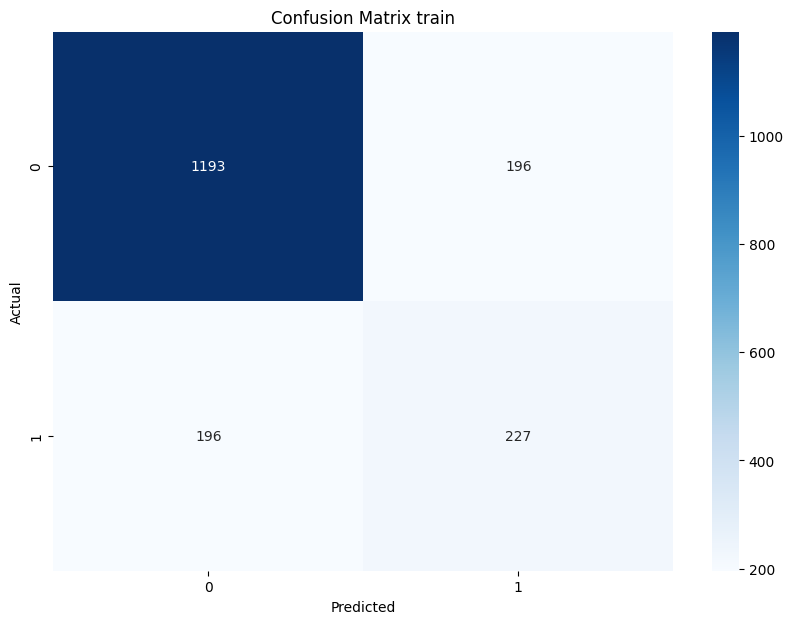

Accuracy: 0.7836644591611479
----------------------------------------------------------------------------------------------------
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86      1389
           1       0.54      0.54      0.54       423

    accuracy                           0.78      1812
   macro avg       0.70      0.70      0.70      1812
weighted avg       0.78      0.78      0.78      1812



In [11]:
# 予測結果を二値クラスに変換
pred_labels = submit["pred_class"]

# 混合行列の作成
cm = confusion_matrix(test_y, pred_labels)

# 混合行列の可視化
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix train')
plt.show()

# 精度評価の表示
print("Accuracy:", accuracy_score(test_y, pred_labels))
print('-' * 100)
print("Classification Report:\n", classification_report(test_y, pred_labels))

In [13]:
# 05_馬券の購入シミュレーション.ipynbで使うためのデータを保存
submit[["race_id", "horse_number", "finish_position", "target", "pred" ,"pred_class"]].to_csv("/content/drive/MyDrive/競馬分析/simulation_data/simulation_20240729.csv", index=False)

In [ ]:
# 全データを使用して再学習
all_X = data.drop(['race_id', 'event_date', 'finish_position', 'target'], axis=1)
all_y = data['target']

# 全データでのlightgbm用データセット
lgb_all = lgb.Dataset(all_X, all_y)

# lightGBMのパラメータ設定
params = {
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.01,
    'feature_fraction': 0.8,
    'bagging_freq': 1,
    'bagging_fraction': 0.8,
    'random_state': 0,
    'objective': 'binary',
    'metric': 'binary_logloss'
}

# モデルの再学習
final_model = lgb.train(params, lgb_all, num_boost_round=model.best_iteration)

# モデルの保存
final_model.save_model('/content/drive/MyDrive/競馬分析/model/final_model.txt')

[LightGBM] [Info] Number of positive: 26562, number of negative: 95018
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.051741 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1496
[LightGBM] [Info] Number of data points in the train set: 121580, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218473 -> initscore=-1.274585
[LightGBM] [Info] Start training from score -1.274585
